In [36]:
import numpy as np
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt


In [37]:
iris_dataset=load_iris()
iris_dataset

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [38]:
D=iris_dataset.data.T
L=iris_dataset.target
classes=iris_dataset.target_names
features=iris_dataset.feature_names

print(f"Le classi sono : {classes} e le features :{features}")

Le classi sono : ['setosa' 'versicolor' 'virginica'] e le features :['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


3


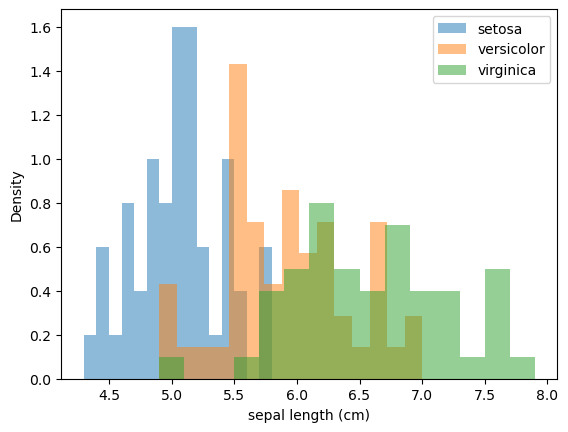

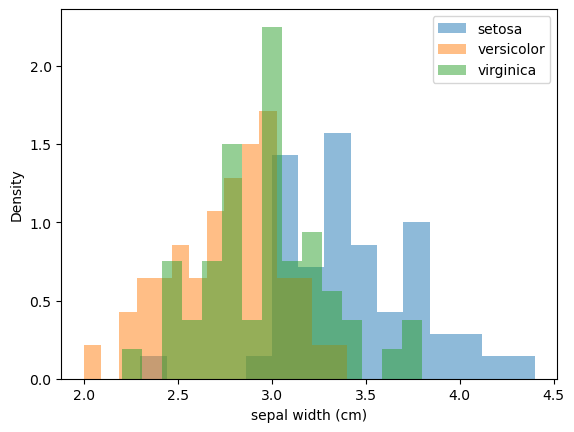

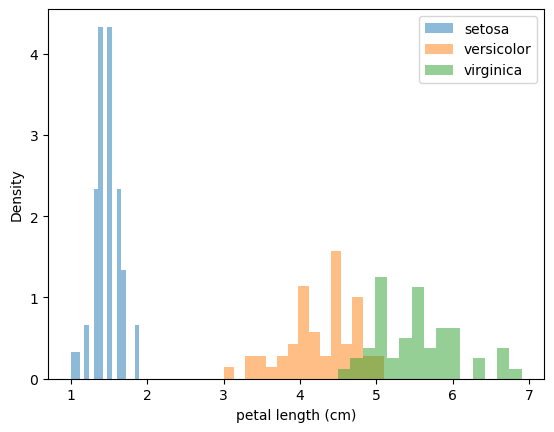

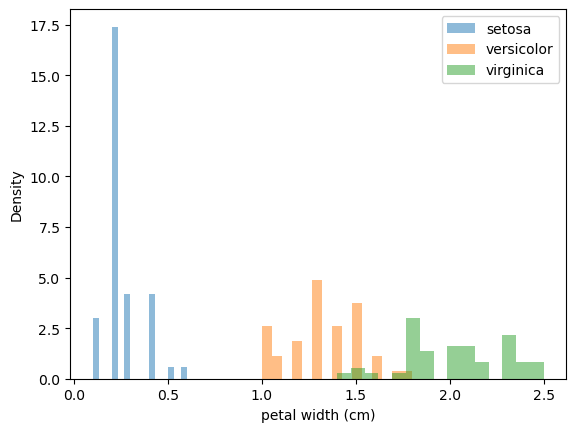

In [ ]:
for i in range(len(features)):
    plt.figure()
    plt.xlabel(f"{features[i]}")
    plt.ylabel("Density")
    for c in range(len(classes)):
        mask= L==c
        D0=D[:,mask][i,:]
        plt.hist(D0,bins=15,density=True,alpha=0.5,label=classes[c])
    
    
    plt.legend()
    plt.show()


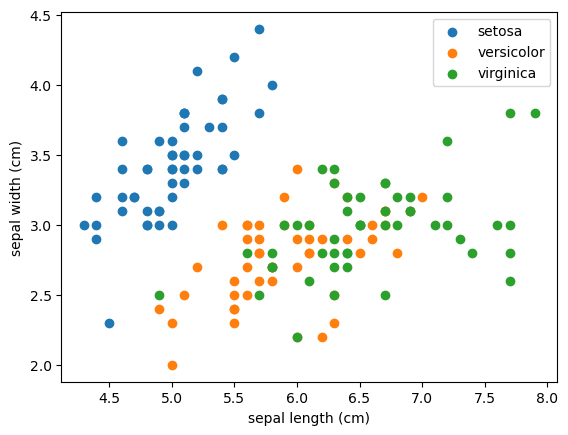

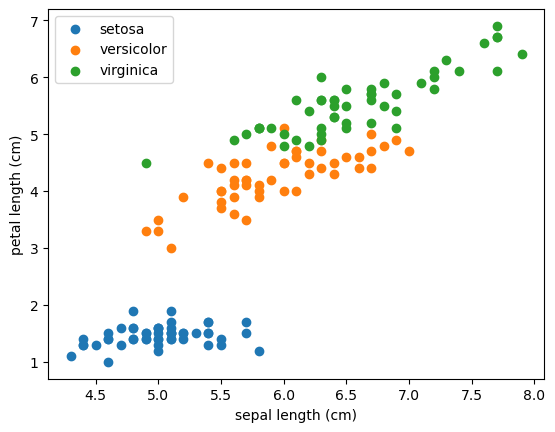

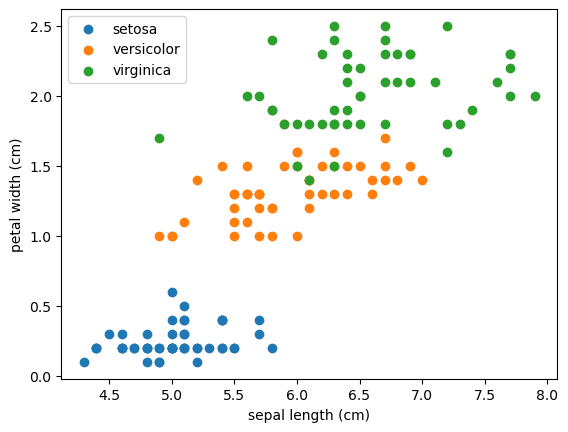

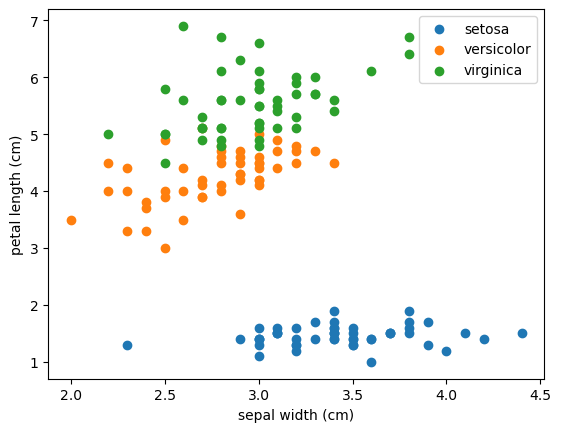

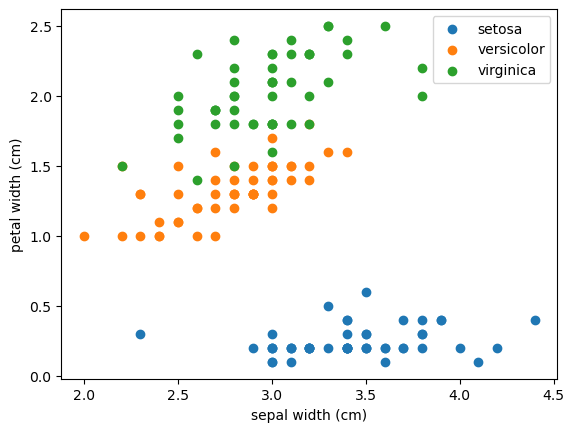

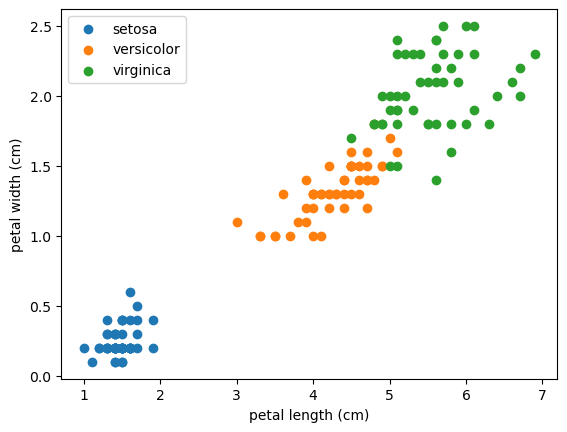

In [34]:
for i in range(len(features)):
    for j in range(i+1,len(features)):
        plt.figure()
        plt.xlabel(f"{features[i]}")
        plt.ylabel(f"{features[j]}")
        for c in range(len(classes)):
            mask=L==c
            D0=D[:,mask]
            plt.scatter(D0[i,:],D0[j,:],label=classes[c])
        
        plt.legend()
        plt.show()

In [39]:
def getMu(D):
    return D.sum(axis=1)/D.shape[1]

def getRow(vet):
    return vet.reshape((1, vet.size))
def getCol(vet):
     return vet.reshape((vet.size, 1))

def getC(D):
    mu=getMu(D)
    mu=getCol(mu)
    Dc=D-mu
    return (Dc @ Dc.T)/Dc.shape[1]


D0=D[:,L==0]
D1=D[:,L==1]

mu0=getMu(D0)
mu1=getMu(D1)
mu=getMu(D)

C0=getC(D0)
C1=getC(D1)
C=getC(D)

print(f"Le medie sono, media globale {mu}, media per i falsi {mu0} e media per i veri {mu1}")
print(f"Le covarianze sono, covarianza globale {C}, covarianza per i falsi {C0} e covarianza per i veri {C1}")

Le medie sono, media globale [5.84333333 3.05733333 3.758      1.19933333], media per i falsi [5.006 3.428 1.462 0.246] e media per i veri [5.936 2.77  4.26  1.326]
Le covarianze sono, covarianza globale [[ 0.68112222 -0.04215111  1.26582     0.51282889]
 [-0.04215111  0.18871289 -0.32745867 -0.12082844]
 [ 1.26582    -0.32745867  3.09550267  1.286972  ]
 [ 0.51282889 -0.12082844  1.286972    0.57713289]], covarianza per i falsi [[0.121764 0.097232 0.016028 0.010124]
 [0.097232 0.140816 0.011464 0.009112]
 [0.016028 0.011464 0.029556 0.005948]
 [0.010124 0.009112 0.005948 0.010884]] e covarianza per i veri [[0.261104 0.08348  0.17924  0.054664]
 [0.08348  0.0965   0.081    0.04038 ]
 [0.17924  0.081    0.2164   0.07164 ]
 [0.054664 0.04038  0.07164  0.038324]]
